# **Part-3**

In [42]:
#Importing the dataset lib
!pip install medmnist


In [43]:
import torch
from torch.utils.data import DataLoader
import medmnist
from medmnist import OCTMNIST

In [44]:
import random
import numpy as np
import torch

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [45]:
train_dataset = OCTMNIST(split='train', download=True)
val_dataset   = OCTMNIST(split='val', download=True)
test_dataset  = OCTMNIST(split='test', download=True)


# **Step-1**

In [46]:
print("Number of training samples:", len(train_dataset))
print("Number of Validation samples:", len(val_dataset))
print("Number of test samples:", len(test_dataset))


Number of training samples: 97477
Number of Validation samples: 10832
Number of test samples: 1000


Data Type: Grayscale retinal OCT images (28×28 pixels, single channel).

Training Samples: 97,477 images

Validation Samples: 10,832 images

Test Samples: 1,000 images

Features: Each image has 784 pixel values (28×28).

Classes: 4 categories

In [47]:
import torchvision.transforms as transforms

image, label = train_dataset[0]

transform = transforms.ToTensor()
image_tensor = transform(image)

print("Image shape:", image_tensor.shape)
print("Label:", label)
print("Label type:", type(label))
print("Image type:", type(image))
print("Image tensor type:", type(image_tensor))

Image shape: torch.Size([1, 28, 28])
Label: [0]
Label type: <class 'numpy.ndarray'>
Image type: <class 'PIL.Image.Image'>
Image tensor type: <class 'torch.Tensor'>


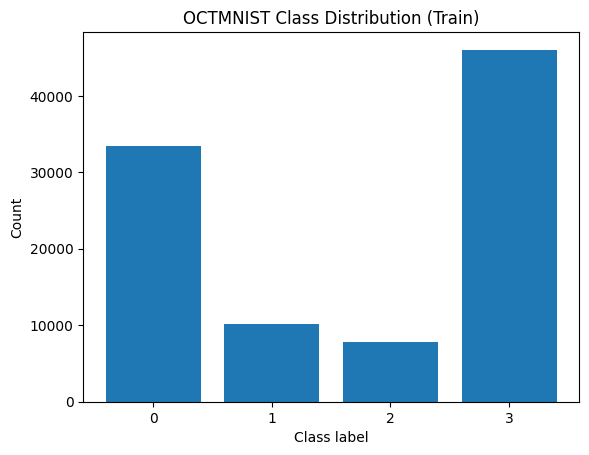

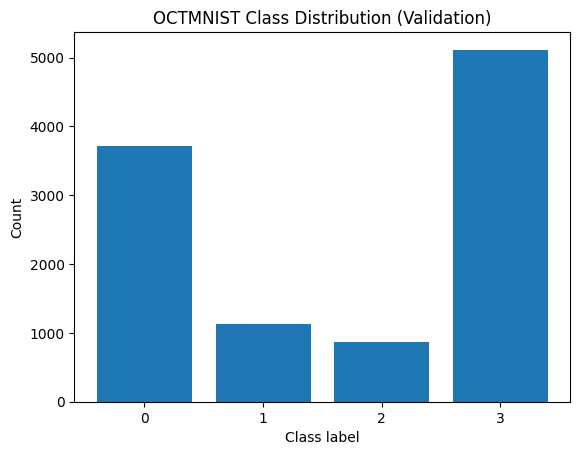

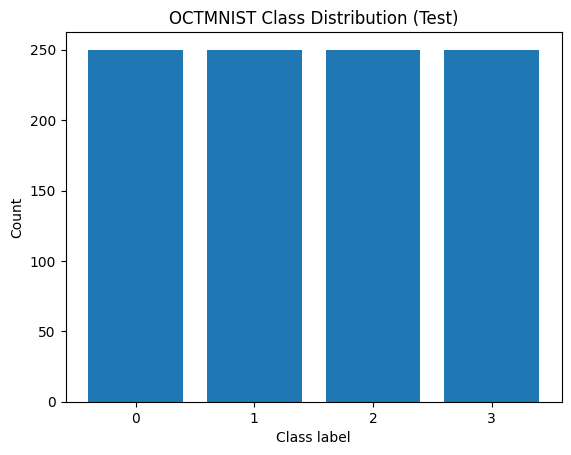

In [48]:
#3
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def get_labels(ds):
    return np.array([int(ds[i][1][0]) for i in range(len(ds))])

y_train = get_labels(train_dataset)
y_val   = get_labels(val_dataset)
y_test  = get_labels(test_dataset)

def plot_class_dist(y, title):
    counts = np.bincount(y)
    plt.figure()
    plt.bar(range(len(counts)), counts)
    plt.xticks(range(len(counts)))
    plt.xlabel("Class label")
    plt.ylabel("Count")
    plt.title(title)
    plt.show()

plot_class_dist(y_train, "OCTMNIST Class Distribution (Train)")
plot_class_dist(y_val,   "OCTMNIST Class Distribution (Validation)")
plot_class_dist(y_test,  "OCTMNIST Class Distribution (Test)")


1)Training Set Class Distribution

This graph shows that the training dataset is clearly imbalanced. Class 3 has the largest number of samples, followed by Class 0, while Classes 1 and 2 have significantly fewer examples.


2)Validation Set Class Distribution

The validation set follows a very similar imbalance pattern to the training set. This is good because it ensures that validation performance reflects what the model actually learned during training.


3)Test Set Class Distribution

Unlike training and validation, the test set is perfectly balanced across all four classes.



In [49]:
#4 Normalisation and importing the train test and val data
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,))
])

train_dataset = OCTMNIST(split='train', transform=train_transform, download=True)
val_dataset   = OCTMNIST(split='val',   transform=test_transform,  download=True)
test_dataset  = OCTMNIST(split='test',  transform=test_transform,  download=True)



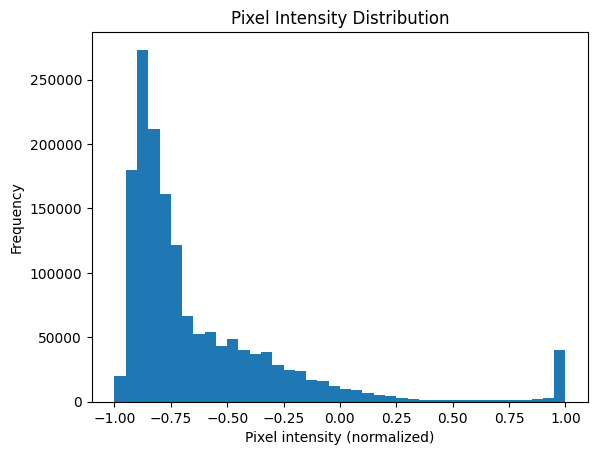

In [50]:
def collect_pixels(ds, n_samples=5000):
    n = min(len(ds), n_samples)
    pixels = []
    for i in range(n):
        image_normalised, _ = ds[i]
        pixels.append(image_normalised.flatten().numpy())
    return np.concatenate(pixels)

pixels_train = collect_pixels(train_dataset, n_samples=2000)

plt.figure()
plt.hist(pixels_train, bins=40)
plt.xlabel("Pixel intensity (normalized)")
plt.ylabel("Frequency")
plt.title("Pixel Intensity Distribution")
plt.show()


The pixel intensity histogram shows that most pixel values are concentrated toward the darker end after normalization. Only a smaller portion of pixels have high intensity values.

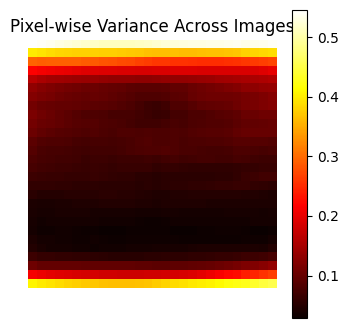

In [51]:
all_imgs = []

for i in range(1000):
    img, _ = train_dataset[i]
    all_imgs.append(img.numpy())

var_img = np.var(all_imgs, axis=0)

plt.figure(figsize=(4,4))
plt.imshow(var_img.squeeze(), cmap="hot")
plt.colorbar()
plt.title("Pixel-wise Variance Across Images")
plt.axis("off")
plt.show()


The variance heatmap shows that certain horizontal regions of the image vary more across samples, while others remain relatively consistent.

In [52]:
#Class Distribution
import numpy as np

def class_stats(ds):
    labels = np.array([int(ds[i][1][0]) for i in range(len(ds))])
    counts = np.bincount(labels)
    percentages = counts / counts.sum() * 100
    return counts, percentages

counts_train, perc_train = class_stats(train_dataset)

for c in range(len(counts_train)):
    print(f"Class {c}: {counts_train[c]} samples ({perc_train[c]:.2f}%)")


Class 0: 33484 samples (34.35%)
Class 1: 10213 samples (10.48%)
Class 2: 7754 samples (7.95%)
Class 3: 46026 samples (47.22%)


# **Step-2**

In [53]:
import torch
import torch.nn as nn

class RetinalCNN(nn.Module):
    def __init__(self, num_classes=4, dropout_p=0.3):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 7 * 7, 128),
            nn.ReLU(),
            nn.Dropout(dropout_p),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


Input:
Grayscale OCT image (1 channel, 28×28).

Feature Extraction (Convolutional Block):

Conv2D (1 = 16 filters, 3×3, padding=1)

Batch Normalization

ReLU activation

MaxPooling (2×2) = reduces 28×28 = 14×14

Conv2D (16 → 32 filters, 3×3, padding=1)

Batch Normalization

ReLU activation

MaxPooling (2×2)  = reduces 14×14 = 7×7

Conv2D (32 = 64 filters, 3×3, padding=1)

Batch Normalization

ReLU activation

(No pooling here to preserve spatial information)

Classifier (Fully Connected Layers):

Flatten layer (64 × 7 × 7 = 3136 features)

Fully Connected Layer (3136 = 128)

ReLU activation

Dropout (p = 0.3) for regularization

Output Layer (128 = 4 classes)

In [74]:
!pip install torchinfo
from torchinfo import summary

model = RetinalCNN(num_classes=4)
summary(model, input_size=(1, 1, 28, 28))


Layer (type:depth-idx)                   Output Shape              Param #
RetinalCNN                               [1, 4]                    --
├─Sequential: 1-1                        [1, 64, 7, 7]             --
│    └─Conv2d: 2-1                       [1, 16, 28, 28]           160
│    └─BatchNorm2d: 2-2                  [1, 16, 28, 28]           32
│    └─ReLU: 2-3                         [1, 16, 28, 28]           --
│    └─MaxPool2d: 2-4                    [1, 16, 14, 14]           --
│    └─Conv2d: 2-5                       [1, 32, 14, 14]           4,640
│    └─BatchNorm2d: 2-6                  [1, 32, 14, 14]           64
│    └─ReLU: 2-7                         [1, 32, 14, 14]           --
│    └─MaxPool2d: 2-8                    [1, 32, 7, 7]             --
│    └─Conv2d: 2-9                       [1, 64, 7, 7]             18,496
│    └─BatchNorm2d: 2-10                 [1, 64, 7, 7]             128
│    └─ReLU: 2-11                        [1, 64, 7, 7]             --
├─Sequ

# **Step-3**

In [54]:
#1)
#Class weights are computed as the inverse of class frequencies to handle class imbalance, ensuring that minority classes are penalized more during training
counts = np.bincount(y_train)
counts = torch.tensor(counts, dtype=torch.float32)
class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum() * len(counts)
device = torch.device("cpu")
class_weights = class_weights.to(device)
loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)

In [55]:
#Optimizer
import torch.optim as optim

model = RetinalCNN(num_classes=4)
optimizer = optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)

In [56]:
def run_epoch(model, loader, train=True):
    model.train() if train else model.eval()

    total_epoch_loss = 0.0
    epoch_predictions = []
    epoch_targets = []

    for batch_features, batch_targets in loader:
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.squeeze().long().to(device)
        if train:
            optimizer.zero_grad()

        batch_logits = model(batch_features)
        batch_loss = loss_function(batch_logits, batch_targets)

        if train:
            batch_loss.backward()
            optimizer.step()

        total_epoch_loss += batch_loss.item() * batch_features.size(0)

        epoch_predictions.append(batch_logits.detach().cpu().numpy())
        epoch_targets.append(batch_targets.detach().cpu().numpy())

    average_loss = total_epoch_loss / len(loader.dataset)
    epoch_predictions = np.concatenate(epoch_predictions, axis=0)
    epoch_targets = np.concatenate(epoch_targets, axis=0)

    return average_loss, epoch_targets, epoch_predictions


In [57]:
# Training Loop- We are running 15 epochs, which I figues out was ideal by different tries
#We are saving the best model based on best Val Accuracy
import time

epochs = 15
best_val_loss = float("inf")
best_val_acc = 0.0
best_model_path = "best_octmnist_cnn.pt"

device = torch.device("cpu")
model.to(device)

batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "epoch_time": []}

start_time = time.time()

for epoch in range(1, epochs + 1):
    epoch_start = time.time()


    train_loss, train_targets, train_outputs = run_epoch(model, train_dataloader, train=True)
    val_loss, val_targets, val_outputs = run_epoch(model, val_dataloader, train=False)


    train_preds = np.argmax(train_outputs, axis=1)
    train_acc = (train_preds == train_targets).mean() * 100

    val_preds = np.argmax(val_outputs, axis=1)
    val_acc = (val_preds == val_targets).mean() * 100

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    epoch_time = time.time() - epoch_start
    history["epoch_time"].append(epoch_time)

    if val_acc > best_val_acc:
      best_val_acc = val_acc
      torch.save(model.state_dict(), "best_octmnist_cnn.pt")


    print(
        f"Epoch {epoch:02d}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
        f"Epoch Time: {epoch_time:.2f}s"
    )

total_time = time.time() - start_time
print(f"\nTotal training time: {total_time:.2f} seconds")
print(f"Best model saved to: {best_model_path} (best val loss = {best_val_loss:.4f})")

Epoch 01/15 | Train Loss: 0.8211 | Train Acc: 70.58% | Val Loss: 0.7230 | Val Acc: 76.02% | Epoch Time: 43.98s
Epoch 02/15 | Train Loss: 0.6631 | Train Acc: 75.64% | Val Loss: 0.5448 | Val Acc: 81.32% | Epoch Time: 55.73s
Epoch 03/15 | Train Loss: 0.6037 | Train Acc: 77.81% | Val Loss: 0.5254 | Val Acc: 78.59% | Epoch Time: 56.44s
Epoch 04/15 | Train Loss: 0.5578 | Train Acc: 79.63% | Val Loss: 0.5177 | Val Acc: 84.56% | Epoch Time: 56.82s
Epoch 05/15 | Train Loss: 0.5198 | Train Acc: 80.99% | Val Loss: 0.5034 | Val Acc: 79.74% | Epoch Time: 58.08s
Epoch 06/15 | Train Loss: 0.4814 | Train Acc: 82.82% | Val Loss: 0.4471 | Val Acc: 85.12% | Epoch Time: 58.62s
Epoch 07/15 | Train Loss: 0.4521 | Train Acc: 83.77% | Val Loss: 0.4565 | Val Acc: 88.03% | Epoch Time: 58.58s
Epoch 08/15 | Train Loss: 0.4291 | Train Acc: 84.71% | Val Loss: 0.4492 | Val Acc: 87.61% | Epoch Time: 61.20s
Epoch 09/15 | Train Loss: 0.4046 | Train Acc: 85.34% | Val Loss: 0.4390 | Val Acc: 83.61% | Epoch Time: 60.43s
E

In [58]:
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

print(f"Loaded best model from: {best_model_path}")

Loaded best model from: best_octmnist_cnn.pt


In [59]:
# Uing the best model to calc test accuracy
import numpy as np
import torch
import torch.nn.functional as F


model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)
model.eval()

total_correct = 0
total_images = 0
cumulative_test_loss = 0.0

predicted_labels_list = []
true_labels_list = []
predicted_probabilities_list = []

with torch.no_grad():
    for batch_images, batch_labels in test_dataloader:
        batch_images = batch_images.to(device)
        batch_labels = batch_labels.squeeze().long().to(device)

        output_logits = model(batch_images)
        batch_loss = loss_function(output_logits, batch_labels)

        batch_probabilities = F.softmax(output_logits, dim=1)
        batch_predictions = torch.argmax(output_logits, dim=1)

        cumulative_test_loss += batch_loss.item() * batch_labels.size(0)
        total_correct += (batch_predictions == batch_labels).sum().item()
        total_images += batch_labels.size(0)

        predicted_labels_list.append(batch_predictions.cpu())
        true_labels_list.append(batch_labels.cpu())
        predicted_probabilities_list.append(batch_probabilities.cpu())

true_labels = torch.cat(true_labels_list).numpy()
predicted_labels = torch.cat(predicted_labels_list).numpy()
predicted_scores = torch.cat(predicted_probabilities_list).numpy()


test_accuracy = 100.0 * total_correct / total_images
test_loss = cumulative_test_loss / total_images

print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Test Loss: {test_loss:.4f}")


Test Accuracy: 77.00%
Test Loss: 1.0281


In [60]:
from sklearn.metrics import precision_recall_fscore_support, classification_report

precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="macro", zero_division=0
)

print("\n Test Performance Metrics")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"F1 Score:      {f1:.4f}")

print("\nDetailed Classification Report:\n")
print(classification_report(true_labels, predicted_labels, zero_division=0))



 Test Performance Metrics
Test Accuracy: 77.00%
Precision:     0.7964
Recall:        0.7700
F1 Score:      0.7490

Detailed Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.88      0.82       250
           1       0.81      0.90      0.85       250
           2       0.91      0.37      0.53       250
           3       0.69      0.93      0.80       250

    accuracy                           0.77      1000
   macro avg       0.80      0.77      0.75      1000
weighted avg       0.80      0.77      0.75      1000



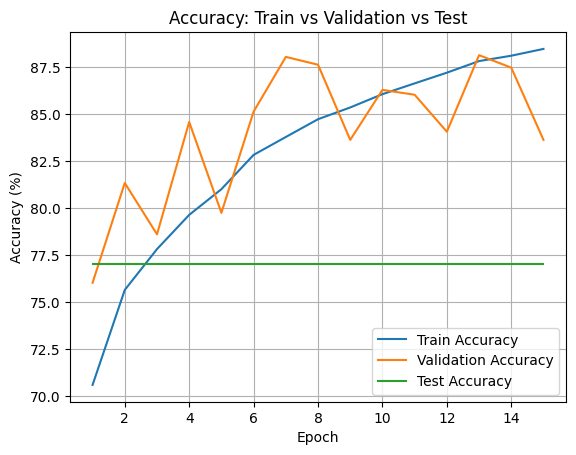

In [61]:
#7)

import matplotlib.pyplot as plt
import numpy as np

epochs =len(history["train_loss"])
epoch_axis = np.arange(1, epochs + 1)

test_acc_line = [test_accuracy] * epochs

plt.figure()
plt.plot(epoch_axis,history["train_acc"],label="Train Accuracy")
plt.plot(epoch_axis,history["val_acc"],label="Validation Accuracy")
plt.plot(epoch_axis, test_acc_line, label="Test Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy: Train vs Validation vs Test")
plt.legend()
plt.grid(True)
plt.show()


# **Accuracy (Train vs Validation vs Test)**

Training accuracy steadily increases, showing the model is learning well.

Validation accuracy improves initially and stabilizes around 85–88%.



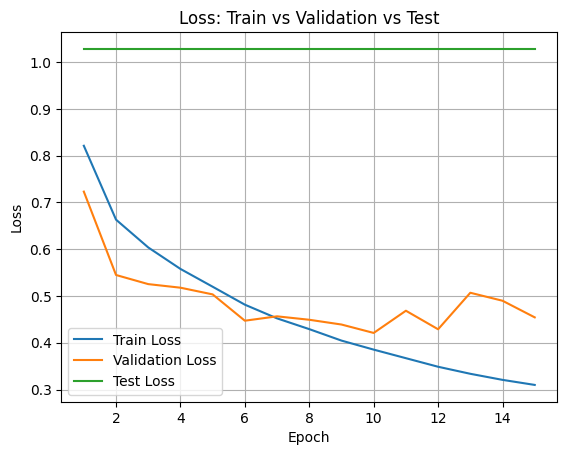

In [62]:
test_loss_line = [test_loss] * epochs

plt.figure()
plt.plot(epoch_axis,history["train_loss"],label="Train Loss")
plt.plot(epoch_axis,history["val_loss"],label="Validation Loss")
plt.plot(epoch_axis, test_loss_line,label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss: Train vs Validation vs Test")
plt.legend()
plt.grid(True)
plt.show()


# **Loss (Train vs Validation vs Test)**

Training loss consistently decreases, confirming stable learning.

Validation loss decreases initially, then fluctuates slightly.

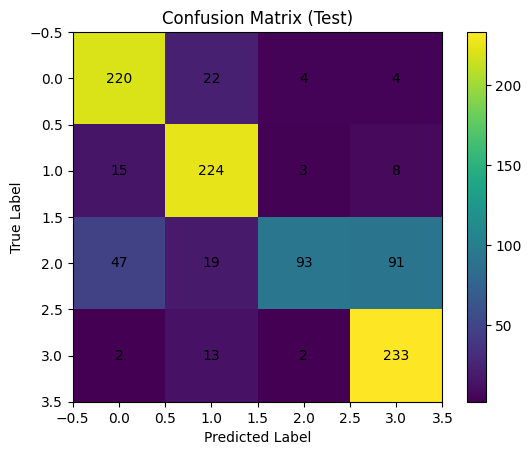

In [63]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

test_confusion_matrix = confusion_matrix(true_labels,predicted_labels)

plt.figure()
plt.imshow(test_confusion_matrix)
plt.title("Confusion Matrix (Test)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()

num_rows, num_cols = test_confusion_matrix.shape
for row in range(num_rows):
    for col in range(num_cols):
        plt.text(col, row, test_confusion_matrix[row, col],ha="center",va="center")

plt.show()


# **Confusion Matrix **

Classes 0, 1, and 3 are classified well with strong diagonal values.

Class 2 shows some values misclassified as Class 3.

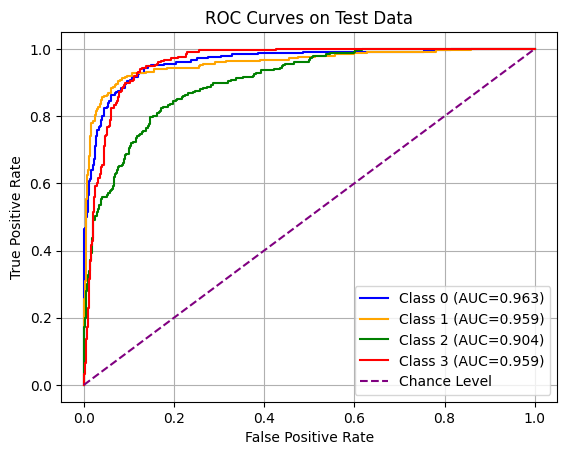

In [64]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

num_classes = predicted_scores.shape[1]
true_labels_onehot = label_binarize(true_labels, classes=list(range(num_classes)))

plt.figure()


curve_colors = ["blue", "orange", "green", "red"]

for class_id in range(num_classes):
    false_positive_rate, true_positive_rate, _ = roc_curve(
        true_labels_onehot[:, class_id],
        predicted_scores[:, class_id]
    )
    class_auc = auc(false_positive_rate, true_positive_rate)

    plt.plot(
        false_positive_rate,
        true_positive_rate,
        color=curve_colors[class_id],
        label=f"Class {class_id} (AUC={class_auc:.3f})"
    )


plt.plot([0, 1], [0, 1], linestyle="--", color="purple", label="Chance Level")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves on Test Data")
plt.legend()
plt.grid(True)
plt.show()


# **ROC Curves **

All classes show strong performance with high AUC values .

Class 0 (AUC = 0.963) performs the best overall.

Class 1 and Class 3 also perform very well .

Class 2 has the lowest AUC (0.904)

# **Improvements to the base model**

# METHOD 1: Gradient Accumulation
# METHOD 2: LR Scheduler
# METHOD 3: Early Stopping

In [65]:
#Modifed the run_epoc function used in base model to accomodate some changes
#Early stopping as been implemened
#Uses learning rate scheduling
#Tracks training history
import torch
import torch.nn as nn
import numpy as np
import time
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

def run_epoch(model, loader, optimizer=None, loss_function=None,
              device="cpu", train=True, accum_steps=1):

    model.train() if train else model.eval()

    total_epoch_loss = 0.0
    epoch_predictions = []
    epoch_targets = []

    for step,(batch_features, batch_targets) in enumerate(loader):
        batch_features = batch_features.to(device)
        batch_targets = batch_targets.squeeze().long().to(device)


        if train and (step % accum_steps == 0):
            optimizer.zero_grad()

        batch_logits = model(batch_features)
        batch_loss = loss_function(batch_logits, batch_targets)

        if train:
            (batch_loss / accum_steps).backward()

            if (step + 1) % accum_steps == 0 or (step + 1) == len(loader):
                optimizer.step()

        total_epoch_loss += batch_loss.item() * batch_features.size(0)
        epoch_predictions.append(batch_logits.detach().cpu().numpy())
        epoch_targets.append(batch_targets.detach().cpu().numpy())

    average_loss   = total_epoch_loss / len(loader.dataset)
    epoch_predictions = np.concatenate(epoch_predictions, axis=0)
    epoch_targets = np.concatenate(epoch_targets, axis=0)

    return average_loss, epoch_targets, epoch_predictions



def train_model(model, train_loader, val_loader, optimizer, loss_function,
                device, epochs=15, accum_steps=1,
                use_scheduler=False, use_early_stopping=False,
                patience=5, model_save_path="best_model.pt"):



    scheduler = None
    if use_scheduler:
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="min",factor=0.5, patience=3 )


    best_val_loss = float("inf")
    best_val_acc  = 0.0
    no_improve_cnt = 0

    history = {
        "train_loss": [], "train_acc": [],
        "val_loss":   [], "val_acc":   [],
        "epoch_time": [], "lr": []}

    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start =time.time()

        train_loss, train_targets, train_outputs = run_epoch(
            model,train_loader,optimizer,loss_function,
            device,train=True, accum_steps=accum_steps
        )
        val_loss,val_targets, val_outputs = run_epoch(
            model,val_loader, optimizer, loss_function,
            device,train=False, accum_steps=1
        )

        train_preds = np.argmax(train_outputs, axis=1)
        train_acc  = (train_preds == train_targets).mean() * 100

        val_preds= np.argmax(val_outputs, axis=1)
        val_acc  = (val_preds == val_targets).mean() * 100

        epoch_time = time.time() - epoch_start
        current_lr = optimizer.param_groups[0]["lr"]

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)
        history["epoch_time"].append(epoch_time)
        history["lr"].append(current_lr)


        if scheduler:
            scheduler.step(val_loss)


        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss= val_loss
            torch.save(model.state_dict(), model_save_path)
            no_improve_cnt = 0
        else:
            no_improve_cnt += 1

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
            f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
            f"LR: {current_lr:.6f} | Time: {epoch_time:.2f}s"
        )


        if use_early_stopping and no_improve_cnt >= patience:
            print(f"\n>> Early stopping at epoch {epoch} (no improvement for {patience} epochs)")
            break

    total_time = time.time() - start_time
    print(f"\nTotal training time: {total_time:.2f}s")
    print(f"Best Val Acc: {best_val_acc:.2f}% | Best Val Loss: {best_val_loss:.4f}")
    print(f"Best model saved to: {model_save_path}")

    return history




In [66]:

#Evaluation metrics has been wrapped in a function
def evaluate_best_model(model, test_loader, loss_function, device,
                        model_path="best_model.pt",
                        class_names=["0", "1", "2", "3"]):

    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"Loaded best weights from: {model_path}\n")

    test_loss, test_targets, test_outputs = run_epoch(
        model, test_loader, optimizer=None, loss_function=loss_function,
        device=device, train=False, accum_steps=1
    )

    test_preds= np.argmax(test_outputs, axis=1)
    test_acc = (test_preds == test_targets).mean() * 100

    print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%\n")
    print("Classification Report:")
    print(classification_report(test_targets, test_preds, target_names=class_names))


    cm = confusion_matrix(test_targets, test_preds)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix — Best Model")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig("confusion_matrix.png", dpi=150)
    plt.show()
    print("Saved: confusion_matrix.png")

    return test_acc




In [67]:
def plot_comparison(base_history, improved_history):

    base_epochs     = range(1, len(base_history["val_acc"]) + 1)
    improved_epochs = range(1, len(improved_history["val_acc"]) + 1)

    # Plot 1: Validation Accuracy
    plt.figure(figsize=(7, 5))
    plt.plot(base_epochs,  base_history["val_acc"],label="Base",marker="o")
    plt.plot(improved_epochs,improved_history["val_acc"],label="Improved", marker="s")
    plt.title("Validation Accuracy: Base vs Improved")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


    plt.figure(figsize=(7, 5))
    plt.plot(base_epochs, base_history["val_loss"],label="Base", marker="o")
    plt.plot(improved_epochs, improved_history["val_loss"], label="Improved", marker="s")
    plt.title("Validation Loss: Base vs Improved")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()



    plt.figure(figsize=(7, 5))
    plt.plot(base_epochs,base_history["epoch_time"],label="Base",marker="o")
    plt.plot(improved_epochs,improved_history["epoch_time"], label="Improved",marker="s")
    plt.title("Epoch Training Time: Base vs Improved")
    plt.xlabel("Epoch")
    plt.ylabel("Seconds")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [68]:


device  = torch.device("cpu")
batch_size = 64
accum_steps = 4

train_dataloader= DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)
counts = np.bincount(y_train)
counts = torch.tensor(counts, dtype=torch.float32)
class_weights = 1.0 / counts
class_weights = class_weights / class_weights.sum() * len(counts)
class_weights = class_weights.to(device)
loss_function = torch.nn.CrossEntropyLoss(weight=class_weights)


base_model = RetinalCNN().to(device)
optimizer  = torch.optim.Adam(base_model.parameters(), lr=1e-3)

base_history = train_model(
    base_model, train_dataloader, val_dataloader,
    optimizer, loss_function, device,
    epochs=15,
    accum_steps=1,
    use_scheduler=False,
    use_early_stopping=False,
    model_save_path="base_model.pt"
)


improved_model = RetinalCNN().to(device)
optimizer  = torch.optim.Adam(improved_model.parameters(), lr=1e-3)

improved_history = train_model(
    improved_model, train_dataloader, val_dataloader,
    optimizer, loss_function, device,
    epochs=15,
    accum_steps=accum_steps,  # METHOD 1: Gradient Accumulation
    use_scheduler=True,       # METHOD 2: LR Scheduler
    use_early_stopping=True,  # METHOD 3: Early Stopping
    patience=5,
    model_save_path="best_model.pt"
)




Epoch 01/15 | Train Loss: 0.7525 | Train Acc: 73.12% | Val Loss: 0.6080 | Val Acc: 82.32% | LR: 0.001000 | Time: 43.52s
Epoch 02/15 | Train Loss: 0.5830 | Train Acc: 79.51% | Val Loss: 0.5161 | Val Acc: 85.23% | LR: 0.001000 | Time: 43.96s
Epoch 03/15 | Train Loss: 0.5246 | Train Acc: 81.57% | Val Loss: 0.5015 | Val Acc: 83.66% | LR: 0.001000 | Time: 46.34s
Epoch 04/15 | Train Loss: 0.4860 | Train Acc: 83.03% | Val Loss: 0.5431 | Val Acc: 82.31% | LR: 0.001000 | Time: 44.14s
Epoch 05/15 | Train Loss: 0.4510 | Train Acc: 84.08% | Val Loss: 0.4296 | Val Acc: 83.81% | LR: 0.001000 | Time: 45.21s
Epoch 06/15 | Train Loss: 0.4255 | Train Acc: 84.96% | Val Loss: 0.4902 | Val Acc: 86.25% | LR: 0.001000 | Time: 44.56s
Epoch 07/15 | Train Loss: 0.4007 | Train Acc: 85.74% | Val Loss: 0.4347 | Val Acc: 88.73% | LR: 0.001000 | Time: 44.20s
Epoch 08/15 | Train Loss: 0.3752 | Train Acc: 86.39% | Val Loss: 0.4995 | Val Acc: 81.93% | LR: 0.001000 | Time: 45.00s
Epoch 09/15 | Train Loss: 0.3543 | Train

In [76]:
import pickle
import torch

weights = torch.load("best_model.pt", map_location=device)

with open("a0_part_3_weights_sourabhr.pkl", "wb") as f:
    pickle.dump(weights, f)

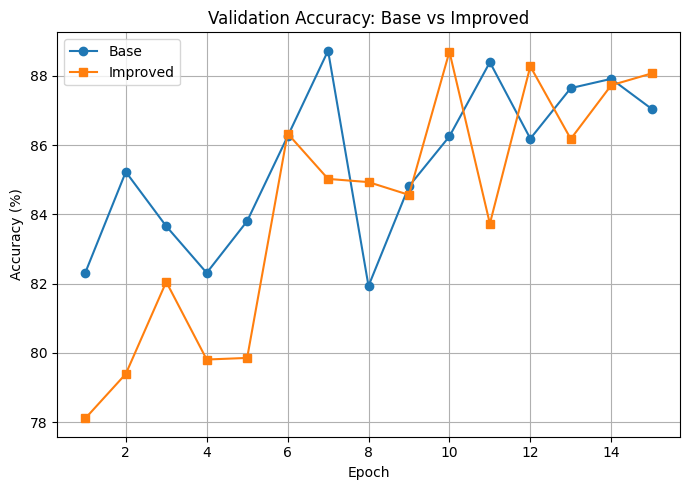

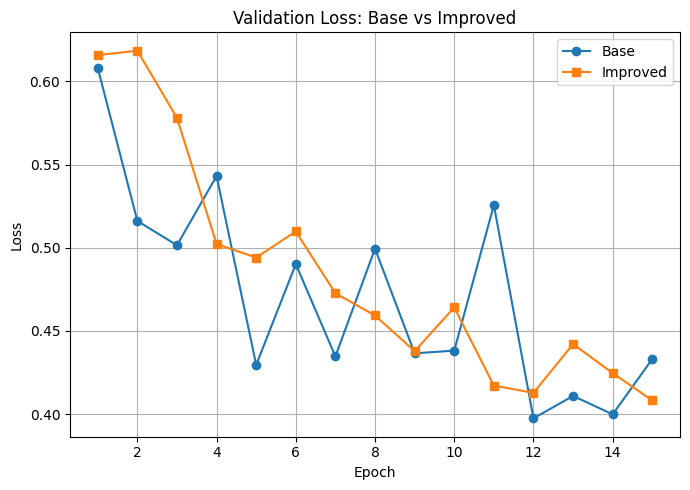

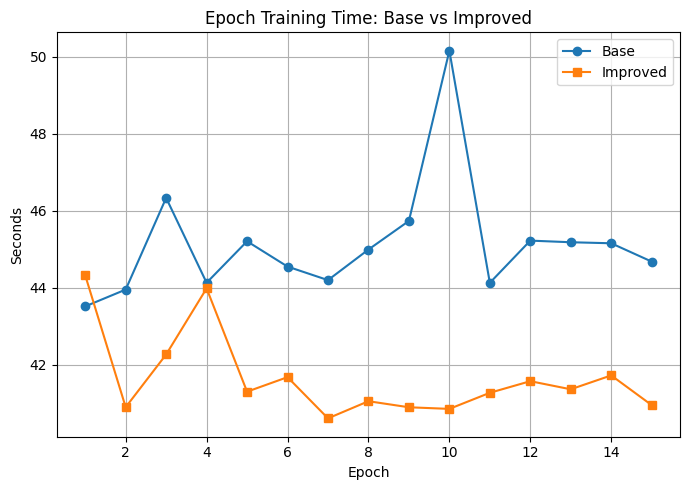

Loaded best weights from: best_model.pt

Test Loss: 1.0104 | Test Accuracy: 76.20%

Classification Report:
              precision    recall  f1-score   support

           0       0.68      0.94      0.79       250
           1       0.91      0.81      0.85       250
           2       0.81      0.40      0.53       250
           3       0.73      0.90      0.81       250

    accuracy                           0.76      1000
   macro avg       0.78      0.76      0.75      1000
weighted avg       0.78      0.76      0.75      1000



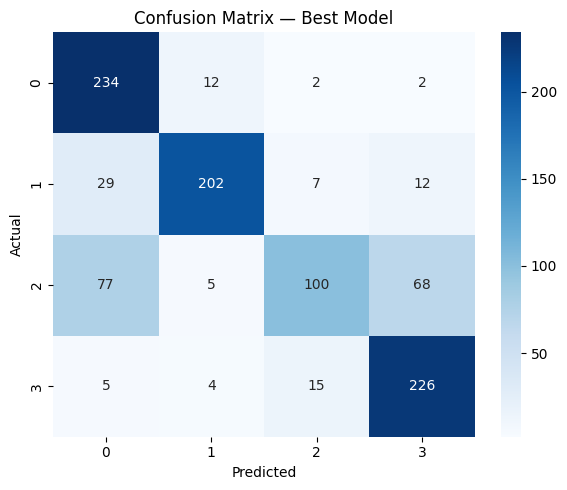

Saved: confusion_matrix.png


np.float64(76.2)

In [69]:
plot_comparison(base_history, improved_history)


evaluate_best_model(improved_model, test_dataloader, loss_function, device,model_path="best_model.pt")

Validation Accuracy: The improved model consistently achieves slightly higher and more stable validation accuracy compared to the base model.

Validation Loss: The improved model shows lower and smoother validation loss overall, indicating better generalization.

Training Time: The improved model trains faster per epoch than the base model while maintaining strong performance.

# **Step-4**

In [79]:
train_dataloader= DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader  = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False)
test_dataloader = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [81]:

images, labels = next(iter(train_dataloader))


image_tensor = images[0].unsqueeze(0)


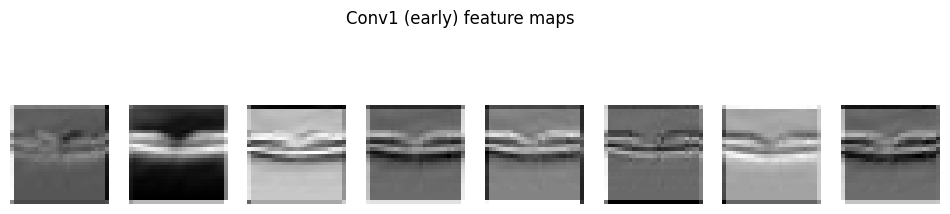

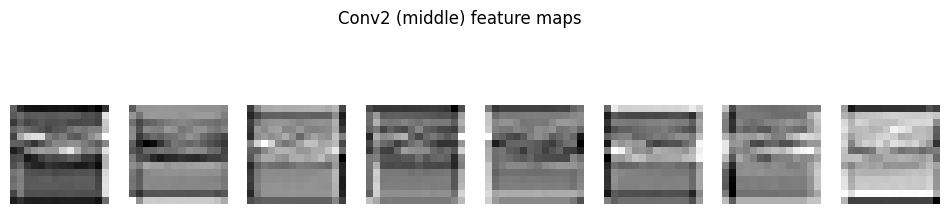

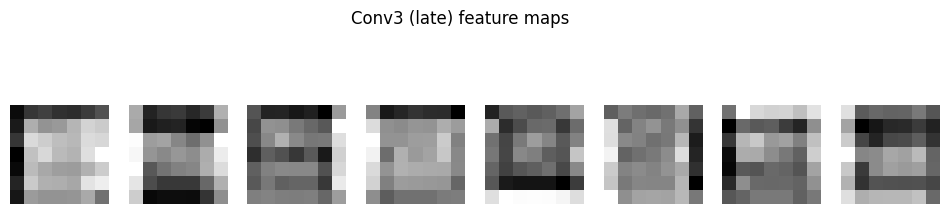

In [83]:
import torch
import matplotlib.pyplot as plt


captured_maps = {}

def capture_output(layer_name):

    def hook_fn(module, input, output):
        captured_maps[layer_name] = output.detach().cpu()
    return hook_fn


conv1 = model.features[0]
conv2 = model.features[4]
conv3 = model.features[8]


hook_conv1 = conv1.register_forward_hook(capture_output("conv1_early"))
hook_conv2 = conv2.register_forward_hook(capture_output("conv2_middle"))
hook_conv3 = conv3.register_forward_hook(capture_output("conv3_late"))

model.to('cpu')

model.eval()
with torch.no_grad():

    _ = model(image_tensor.to('cpu'))

hook_conv1.remove()
hook_conv2.remove()
hook_conv3.remove()


def show_feature_maps(feature_tensor, title, max_channels=8):

    num_channels = feature_tensor.shape[1]
    n = min(max_channels, num_channels)

    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(feature_tensor[0, i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


show_feature_maps(captured_maps["conv1_early"],  "Conv1 (early) feature maps")
show_feature_maps(captured_maps["conv2_middle"], "Conv2 (middle) feature maps")
show_feature_maps(captured_maps["conv3_late"],   "Conv3 (late) feature maps")

**Early Layer (Conv1)**

Detects simple edges, brightness changes, and strong horizontal retinal boundaries.

Focuses on basic visual patterns without understanding disease structure.

**Middle Layer (Conv2)**

Combines edges to capture layered retinal textures and structural patterns.


**Late Layer (Conv3)**


Suppresses background noise and keeps only highly relevant activations.

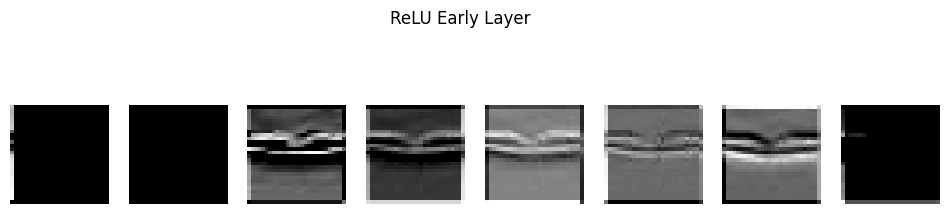

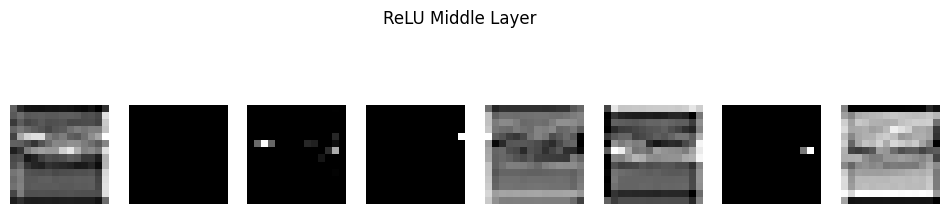

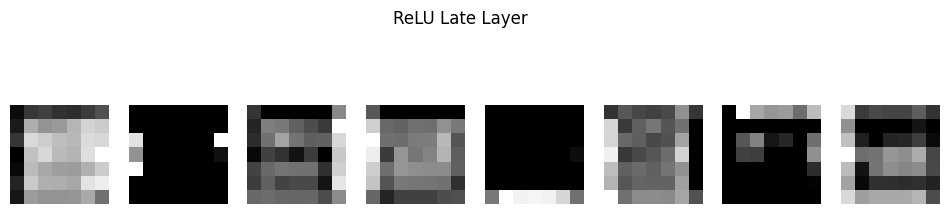

In [84]:
import torch
import matplotlib.pyplot as plt

relu_maps = {}


def capture_relu_output(layer_name):
    def hook_fn(module, input, output):
        relu_maps[layer_name] = output.detach().cpu()
    return hook_fn


relu_early = model.features[2]
relu_middle = model.features[6]
relu_late  = model.features[10]


hook1 = relu_early.register_forward_hook(capture_relu_output("early"))
hook2 = relu_middle.register_forward_hook(capture_relu_output("middle"))
hook3 = relu_late.register_forward_hook(capture_relu_output("late"))

model.to('cpu')

model.eval()
with torch.no_grad():
    _ = model(image_tensor.to(device))

hook1.remove()
hook2.remove()
hook3.remove()

def visualize_relu_maps(feature_tensor, title, max_channels=8):
    num_channels = feature_tensor.shape[1]
    n = min(max_channels, num_channels)

    plt.figure(figsize=(12, 3))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(feature_tensor[0, i], cmap="gray")
        plt.axis("off")
    plt.suptitle(title)
    plt.show()


visualize_relu_maps(relu_maps["early"],  "ReLU Early Layer")
visualize_relu_maps(relu_maps["middle"], "ReLU Middle Layer")
visualize_relu_maps(relu_maps["late"],   "ReLU Late Layer")


**ReLU Early Layer**

The early ReLU layer highlights strong retinal edges and boundaries while suppressing weak or irrelevant background signals.

Background regions and weak signals are suppressed (appear dark).

**ReLU Middle Layer**

Layers with structure are emphasized.

Flat or uniform areas of the image are mostly suppressed.

**ReLU Late Layer**

Only highly relevant regions remain active.

Most irrelevant or redundant areas are suppressed.

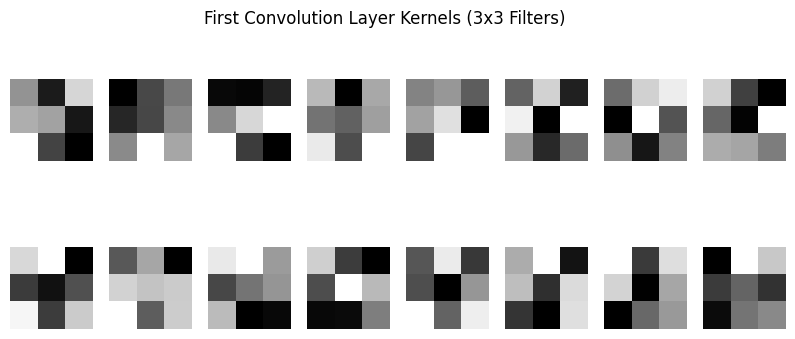

In [85]:
import matplotlib.pyplot as plt


first_conv_layer = model.features[0]
kernel_weights = first_conv_layer.weight.detach().cpu()
num_kernels = kernel_weights.shape[0]

plt.figure(figsize=(10, 4))

for i in range(num_kernels):
    plt.subplot(2, num_kernels // 2, i + 1)

    kernel_image = kernel_weights[i, 0]

    plt.imshow(kernel_image, cmap="gray")
    plt.axis("off")

plt.suptitle("First Convolution Layer Kernels (3x3 Filters)")
plt.show()


In [86]:
state = torch.load("best_model.pt", map_location="cpu")
for key, val in state.items():
    print(key, val.shape)

features.0.weight torch.Size([16, 1, 3, 3])
features.0.bias torch.Size([16])
features.1.weight torch.Size([16])
features.1.bias torch.Size([16])
features.1.running_mean torch.Size([16])
features.1.running_var torch.Size([16])
features.1.num_batches_tracked torch.Size([])
features.4.weight torch.Size([32, 16, 3, 3])
features.4.bias torch.Size([32])
features.5.weight torch.Size([32])
features.5.bias torch.Size([32])
features.5.running_mean torch.Size([32])
features.5.running_var torch.Size([32])
features.5.num_batches_tracked torch.Size([])
features.8.weight torch.Size([64, 32, 3, 3])
features.8.bias torch.Size([64])
features.9.weight torch.Size([64])
features.9.bias torch.Size([64])
features.9.running_mean torch.Size([64])
features.9.running_var torch.Size([64])
features.9.num_batches_tracked torch.Size([])
classifier.1.weight torch.Size([128, 3136])
classifier.1.bias torch.Size([128])
classifier.4.weight torch.Size([4, 128])
classifier.4.bias torch.Size([4])


In [92]:
#Video demonstration pupuse - To doenload test images to test the model.
'''from PIL import Image
import numpy as np
from medmnist import OCTMNIST

test_dataset_raw = OCTMNIST(split='test', download=True, transform=None)

saved = {}
for img, label in test_dataset_raw:
    label = int(label)
    if label not in saved:
        img_large = img.resize((224, 224), Image.NEAREST)
        img_large.save(f"class_test__{label}.png")
        saved[label] = True
    if len(saved) == 4:
        break

print("Saved: class_0.png, class_1.png, class_2.png, class_3.png")'''

Saved: class_0.png, class_1.png, class_2.png, class_3.png


/tmp/ipython-input-1444975363.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(label)


# **References:**



*   Dataset used  - https://medmnist.com/ and
https://zenodo.org/record/6496656

*   MedMNIST- https://github.com/MedMNIST/MedMNIST

*   Pytorch tutorials - https://pytorch.org/tutorials/beginner/deep_learning_60min_blitz.html

*   Matplotlib - https://matplotlib.org/stable/index.html


*   Optim - https://docs.pytorch.org/docs/stable/optim.html

*   Python Docs - https://docs.python.org/3/library/time.html



*   Sci-kit learn documentation- https://scikit-learn.org/0.21/documentation.html


*   Pandas documentation- https://pandas.pydata.org/docs/